# HEALPix Influence Game

This notebook contains the complete implementation of the Influence-Aware Decision Making term project.

## Project Timeline
- **Week 1**: Game mechanics, Map, and Greedy Agent.
- **Week 2**: Influence-Aware Agent and Visualization.
- **Week 3**: Comparative Analysis, Map Design Variation, and Parameter Sensitivity.


## Week 1: Game Mechanics & Greedy Agent

In this section, we implement the core game loop, the HEALPix map environment, and the baseline Greedy Agent.

In [1]:
import healpy as hp
import numpy as np
import random
from abc import ABC, abstractmethod
import time
import matplotlib.pyplot as plt
from IPython.display import HTML, display, Image
import os

# --- Game Constants ---
NSIDE = 2
NPIX = hp.nside2npix(NSIDE)  # Total pixels: 48 for NSIDE=2
COST_SETTLE = 2
COST_ROAD = 1
INITIAL_COINS = 2
WIN_ROUNDS = 1  # Consecutive full rounds without actions to declare game end

# --- Visualization Standards ---
VIS_PARAMS = {
    "cmap": "viridis",
    "min": 0,
    "max": 5,
    "cbar": True
}

print(f"Game initialized with NSIDE={NSIDE}, NPIX={NPIX}")

Game initialized with NSIDE=2, NPIX=48


In [2]:
class HealpixMap:
    """
    Represents the game board using HEALPix pixelation (Spherical Topology).
    Manages weights, adjacency (neighbors), and ownership state (settlements/roads).
    """
    def __init__(self):
        self.nside = NSIDE
        self.npix = NPIX
        # Initialize weights w(p) in {1, 3, 5}
        rng = np.random.RandomState(42)
        self.weights = rng.choice([1, 3, 5], size=self.npix)
        
        # Adjacency: precompute neighbors using healpy
        # ASSIGNMENT COMPLIANCE: Adjacency is given by the HEALPix neighbor graph (Spherical Topology).
        raw_neighbors = [hp.get_all_neighbours(self.nside, i, nest=True) for i in range(self.npix)]
        
        # Filter out -1s (missing neighbors key)
        self.neighbors = [[n for n in nb if n != -1] for nb in raw_neighbors]
        
        # State tracking
        self.settlements = {}  # pixel_id -> player_id
        self.road_owners = {}  # (u,v) -> player_id

    def get_neighbors(self, pixel_id):
        """Return list of adjacent pixel IDs."""
        return self.neighbors[pixel_id]
    
    def is_occupied(self, pixel_id):
        """Check if a settlement exists on this pixel."""
        return pixel_id in self.settlements
        
    def has_road(self, u, v):
        """Check if a road exists between u and v."""
        u, v = sorted((u, v))
        return (u, v) in self.road_owners

    def build_settlement(self, pixel_id, player_id):
        """Place a settlement for player_id at pixel_id."""
        if self.is_occupied(pixel_id):
            raise ValueError(f"Pixel {pixel_id} is already occupied.")
        self.settlements[pixel_id] = player_id
        
    def build_road(self, u, v, player_id):
        """Place a road for player_id between u and v."""
        u, v = sorted((u, v))
        if (u, v) in self.road_owners:
            raise ValueError(f"Road {u}-{v} already exists.")
        self.road_owners[(u, v)] = player_id
        
    def print_adjacency(self):
        """Debug utility to view graph structure."""
        print("--- Game Board Adjacency (HEALPix Sphere) ---")
        print("{:<10} | {:<30}".format("Pixel ID", "Neighbors"))
        print("-"*45)
        for p in range(self.npix):
            nb_str = str(sorted(self.neighbors[p]))
            print("{:<10} | {:<30}".format(p, nb_str))
        print("-"*45)

In [3]:
class BaseAgent(ABC):
    """
    Abstract Base Class for all agents.
    Ensures valid interface for decide_action.
    """
    def __init__(self, player_id):
        self.player_id = player_id
        self.coins = INITIAL_COINS
        self.start_pixel = None
        
    def set_start_pixel(self, pixel_id):
        self.start_pixel = pixel_id
        
    @abstractmethod
    def decide_action(self, game_state):
        """
        Returns tuple (action_type, target)
        action_type: 'settle', 'build_road', 'do_nothing'
        target: pixel_id (for settle) or (u, v) (for build_road)
        """
        pass


In [4]:
class GreedyAgent(BaseAgent):
    """
    A simple agent that always expands to the highest-weight immediate opportunity.
    Priority: Settle > Build Road > Wait.
    """
    def decide_action(self, game_state):
        # 1. Reachability
        reachable = game_state.get_reachable_pixels(self.player_id)
        
        # --- Settle Logic ---
        valid_settle_targets = []
        for p in reachable:
            # "Built on a reachable, empty region"
            if not game_state.map.is_occupied(p):
                valid_settle_targets.append(p)
                
        if self.coins >= COST_SETTLE and valid_settle_targets:
            # Greedy: Highest weight
            best_target = max(valid_settle_targets, key=lambda p: game_state.map.weights[p])
            return ('settle', best_target)
            
        # --- Build Road Logic ---
        if self.coins >= COST_ROAD:
            valid_roads = []
            # "Road may only be built from a reachable pixel to an adjacent UNOWNED pixel"
            for p in reachable:
                neighbors = game_state.map.get_neighbors(p)
                for n in neighbors:
                    if not game_state.map.has_road(p, n):
                        # Check strict constraints here to avoid invalid moves
                        # Constraint 1: Target unowned
                        if not game_state.map.is_occupied(n):
                             # Constraint 2: Non-redundant (n not already reachable)
                             if n not in reachable:
                                 valid_roads.append((p, n))

            if valid_roads:
                 # Greedy road: Leads to highest weight neighbor
                 best_road = max(valid_roads, key=lambda r: game_state.map.weights[r[1]])
                 return ('build_road', best_road)
                 
        return ('do_nothing', None)

In [5]:
class Game:
    """
    The robust Game Engine.
    Manages: Turn sequencing, Resource collection, Action validation, State history.
    """
    def __init__(self, agent1, agent2):
        self.map = HealpixMap()
        self.agents = [agent1, agent2]
        self.turn_count = 0
        self.consecutive_idle_rounds = 0
        self.max_idle_rounds = WIN_ROUNDS
        self.history = []
        
        # Initialize starting positions
        # "Each agent starts with one randomly assigned initial region"
        start_pixels = np.random.choice(range(NPIX), size=2, replace=False)
        
        for i, agent in enumerate(self.agents):
            agent.set_start_pixel(start_pixels[i])
            self.map.build_settlement(start_pixels[i], agent.player_id)
        
        self.record_state()
            
    def get_reachable_pixels(self, player_id):
        """
        Perform BFS to find all pixels connected to the start_pixel via owned roads.
        """
        start_node = self.agents[player_id].start_pixel
        reachable = {start_node}
        queue = [start_node]
        
        while queue:
            current = queue.pop(0)
            neighbors = self.map.get_neighbors(current)
            for n in neighbors:
                u, v = sorted((current, n))
                # Check if road exists and is owned by player
                if (u, v) in self.map.road_owners and self.map.road_owners[(u,v)] == player_id:
                    if n not in reachable:
                        reachable.add(n)
                        queue.append(n)
        return list(reachable)

    def collect_resources(self, agent_index):
        """Collect income for a specific agent at start of their turn."""
        agent = self.agents[agent_index]
        income = 0
        for pix, owner in self.map.settlements.items():
            if owner == agent.player_id:
                income += self.map.weights[pix]
        agent.coins += income

    def record_state(self, action_desc="Start"):
        # Deep copy state for history analysis
        state = {
            'turn': self.turn_count,
            'settlements': self.map.settlements.copy(),
            'road_owners': self.map.road_owners.copy(),
            'coins': [a.coins for a in self.agents],
            'action': action_desc
        }
        self.history.append(state)
            
    def validate_action(self, player_id, action, target):
        """Check if an action is legal according to game rules."""
        agent = self.agents[player_id]
        
        if action == 'do_nothing':
            return True, None
            
        reachable = self.get_reachable_pixels(player_id)
        
        if action == 'settle':
            # Cost Check
            if agent.coins < COST_SETTLE:
                return False, "Insufficient coins"
            
            # Reachability Check
            # "Settlements can only be built on reachable regions"
            if target not in reachable:
                return False, "Target not reachable"
            
            # Occupancy Check
            # "One settlement per region"
            if self.map.is_occupied(target):
                return False, "Target occupied"
            
            return True, None
            
        if action == 'build_road':
            if agent.coins < COST_ROAD:
                return False, "Insufficient coins"
            
            u, v = sorted(target)
            
            # Existence Check
            # "A single connection belongs to a single player (i.e. duble road prohibited)"
            if self.map.has_road(u, v):
                return False, "Road already exists"
                
            # Strict Rule: "Road may only be built from a reachable pixel to an adjacent unowned pixel"
            # AND "Exist only to make new regions reachable" -> No redundant roads.
            
            u_reachable = u in reachable
            v_reachable = v in reachable
            
            if not (u_reachable or v_reachable):
                return False, "Road not connected to network"
            
            # Check for redundancy (Cycles)
            if u_reachable and v_reachable:
                return False, "Redundant road (both endpoints already reachable)"
            
            # Identify Source and Target
            # The non-reachable one is the Target. It MUST be unowned (per rule).
            if u_reachable and not v_reachable:
                # Target is V
                if self.map.is_occupied(v):
                    return False, "Target pixel (V) is occupied"
            elif v_reachable and not u_reachable:
                # Target is U
                if self.map.is_occupied(u):
                    return False, "Target pixel (U) is occupied"
            
            return True, None
            
        return False, "Unknown action"

    def step(self, verbose=True):
        """Executes one full round (one turn for each player)."""
        actions_taken = 0
        
        # Execute turn for each player SEQUENTIALLY
        for i, agent in enumerate(self.agents):
            # 1. Collect Resources
            self.collect_resources(i)
            
            # 2. Decide Action
            action, target = agent.decide_action(self)
            desc = ""
            
            # 3. Validate & Execute
            is_valid, reason = self.validate_action(i, action, target)
            
            if is_valid:
                if action == 'settle':
                    self.map.build_settlement(target, i)
                    agent.coins -= COST_SETTLE
                    desc = f"P{i} Settle {target}"
                    if verbose:
                        print(f"Turn {self.turn_count}.{i}: Player {i} [Coins: {agent.coins}] SETTLES at {target} (Weight {self.map.weights[target]})")
                    actions_taken += 1
                elif action == 'build_road':
                    u, v = target
                    self.map.build_road(u, v, i)
                    agent.coins -= COST_ROAD
                    desc = f"P{i} Road {u}-{v}"
                    if verbose:
                        print(f"Turn {self.turn_count}.{i}: Player {i} [Coins: {agent.coins}] BUILDS ROAD {u}-{v}")
                    actions_taken += 1
                else:
                    desc = f"P{i} Wait"
                    pass
            else:
                if verbose and action != 'do_nothing':
                    print(f"Turn {self.turn_count}.{i} P{i} [Coins: {agent.coins}] INVALID ({action} {target}): {reason}")
                desc = f"P{i} Invalid ({reason})"
            
            self.record_state(desc)
                
        if actions_taken == 0:
            self.consecutive_idle_rounds += 1
        else:
            self.consecutive_idle_rounds = 0
            
        self.turn_count += 1

    def play(self, verbose=True, plot_influence_for_player=None):
        """
        Main Loop: Runs the game until win condition or max turns.
        """
        if verbose:
            self.map.print_adjacency()
            print("Starting Game...")
            print(f"Start Pixels: P0={self.agents[0].start_pixel}, P1={self.agents[1].start_pixel}")
        
        snapshots = [10, 20, 30]
        
        while self.consecutive_idle_rounds < self.max_idle_rounds:
            self.step(verbose=verbose)
            
            if plot_influence_for_player is not None and self.turn_count in snapshots:
                 agent = self.agents[plot_influence_for_player]
                 if hasattr(agent, 'compute_influence'):
                     print(f"--- Snapshot: Influence Map at Turn {self.turn_count} ---")
                     inf_map = agent.compute_influence(self)
                     visualize_influence(inf_map, game_instance=self, title=f"Influence Map Turn {self.turn_count} (Player {plot_influence_for_player})")
            
            # Safety break
            if self.turn_count > 200:
                if verbose: print("Max turns reached.")
                break
                
        if verbose:
            print("Game Over!")
            print(f"Final Coins: P0={self.agents[0].coins}, P1={self.agents[1].coins}")
            p0_settlements = sum(1 for owner in self.map.settlements.values() if owner == 0)
            p1_settlements = sum(1 for owner in self.map.settlements.values() if owner == 1)
            print(f"Settlements: P0={p0_settlements}, P1={p1_settlements}")
            return self.history


In [6]:
print("--- Simulation: Week 1 Greedy vs Greedy ---")
# Re-seed for consistency in this run
np.random.seed(101)
agent0 = GreedyAgent(0)
agent1 = GreedyAgent(1)
game_w1 = Game(agent0, agent1)
history_w1 = game_w1.play()

--- Simulation: Week 1 Greedy vs Greedy ---
--- Game Board Adjacency (HEALPix Sphere) ---
Pixel ID   | Neighbors                     
---------------------------------------------
0          | [np.int64(1), np.int64(2), np.int64(3), np.int64(17), np.int64(19), np.int64(22), np.int64(23), np.int64(35)]
1          | [np.int64(0), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(22), np.int64(23)]
2          | [np.int64(0), np.int64(1), np.int64(3), np.int64(13), np.int64(15), np.int64(17), np.int64(19)]
3          | [np.int64(0), np.int64(1), np.int64(2), np.int64(6), np.int64(7), np.int64(11), np.int64(13), np.int64(15)]
4          | [np.int64(5), np.int64(6), np.int64(7), np.int64(21), np.int64(23), np.int64(26), np.int64(27), np.int64(39)]
5          | [np.int64(4), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(26), np.int64(27)]
6          | [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(21), np.int64(23)]
7          | [np.int6

## Week 2: Influence-Aware Agent

This section contains the implementation of the Influence-Aware agent.

In [7]:
def visualize_influence(influence_map, game_instance=None, title="Influence Map"):
    """
    Visualizes the influence map using healpy.mollview.
    Includes Pixel IDs and overlays current Game State (Roads/Settlements).
    Includes robust filter for map-crossing lines (flat-map optimization for 2D viewing).
    """
    plt.figure(figsize=(10, 6))
    hp.mollview(influence_map, 
                title=title, 
                nest=True, 
                cmap=VIS_PARAMS["cmap"], 
                min=VIS_PARAMS["min"], 
                max=VIS_PARAMS["max"],
                cbar=VIS_PARAMS["cbar"],
                hold=True)
    
    # 1. Overlay Game State if provided
    if game_instance:
        # Roads
        for (u, v), owner in game_instance.map.road_owners.items():
            color = 'red' if owner == 0 else 'blue'
            t1, p1 = hp.pix2ang(NSIDE, u, nest=True)
            t2, p2 = hp.pix2ang(NSIDE, v, nest=True)
            
            # Robust wrap-around check: If Longitude diff > Pi, do not draw the line.
            # This prevents ugly horizontal streaks on the 2D map while preserving spherical logic.
            if abs(p1 - p2) < np.pi:
                hp.projplot([t1, t2], [p1, p2], color=color, linewidth=3.0, linestyle='-')
        
        # Settlements
        for pix, owner in game_instance.map.settlements.items():
            color = 'red' if owner == 0 else 'blue'
            theta, phi = hp.pix2ang(NSIDE, pix, nest=True)
            hp.projscatter(theta, phi, color=color, s=200, marker='o', edgecolor='white', linewidth=2.0)

    # 2. Always write pixel numbers
    for pix in range(len(influence_map)): 
        theta, phi = hp.pix2ang(NSIDE, pix, nest=True)
        hp.projtext(theta, phi, str(pix), color='black', fontsize=8, ha='center', va='center', weight='normal')
        
    plt.show()

In [8]:
class InfluenceAgent(BaseAgent):
    """
    Strategic Agent maximizing Influence I(p) = L(p) * R(p) * F(p).
    - L(p): Local Weight (resource value)
    - R(p): Reachability Factor (1.0 if owned, alpha if neighbor)
    - F(p): Friction Factor (0.5 if opponent road nearby, else 1.0)
    """
    def __init__(self, player_id, alpha=0.6):
        super().__init__(player_id)
        self.alpha = alpha

    def compute_influence(self, game_state):
        influence_map = np.zeros(game_state.map.npix)
        
        # Helper to check reachability
        my_reachable = game_state.get_reachable_pixels(self.player_id)
        
        # Identify 1-road away pixels
        one_road_away = set()
        for p in my_reachable:
            neighbors = game_state.map.get_neighbors(p)
            for n in neighbors:
                if n not in my_reachable:
                    if not game_state.map.is_occupied(n):
                         one_road_away.add(n)
        
        opponent_id = 1 - self.player_id
        
        for p in range(game_state.map.npix):
            # L(p) = w(p)
            L = game_state.map.weights[p]
            
            # R(p)
            if p in my_reachable:
                R = 1.0
            elif p in one_road_away:
                R = self.alpha
            else:
                R = 0.0
                
            # F(p)
            has_opponent_road = False
            neighbors = game_state.map.get_neighbors(p)
            for n in neighbors:
                 if game_state.map.has_road(p, n):
                     # Check owner
                     u, v = sorted((p, n))
                     if game_state.map.road_owners[(u,v)] == opponent_id:
                         has_opponent_road = True
                         break
            
            if has_opponent_road:
                F = 0.5
            else:
                F = 1.0
                
            influence_map[p] = L * R * F
            
        return influence_map

    def decide_action(self, game_state):
        influence = self.compute_influence(game_state)
        
        # 1. Best Settlement (Reachable)
        my_reachable = game_state.get_reachable_pixels(self.player_id)
        best_settle_p = None
        best_settle_val = -1
        
        for p in my_reachable:
            if not game_state.map.is_occupied(p):
                val = influence[p]
                if val > best_settle_val:
                    best_settle_val = val
                    best_settle_p = p
                    
        # 2. Best Road Target (1-road away)
        one_road_away = []
        for p in my_reachable:
            neighbors = game_state.map.get_neighbors(p)
            for n in neighbors:
                 if n not in my_reachable:
                      if not game_state.map.is_occupied(n):
                           one_road_away.append((n, p)) # target n, source p
        
        best_road_target = None
        best_road_source = None
        best_road_val = -1

        for target, source in one_road_away:
            val = influence[target]
            if val > best_road_val:
                best_road_val = val
                best_road_target = target
                best_road_source = source

        # Decision Logic
        should_settle = False
        if self.coins >= COST_SETTLE and best_settle_p is not None:
            if self.coins >= COST_ROAD and best_road_target is not None:
                if best_settle_val >= best_road_val:
                    should_settle = True
                else:
                    should_settle = False
            else:
                 should_settle = True
        
        if should_settle:
             return ('settle', best_settle_p)
        elif self.coins >= COST_ROAD and best_road_target is not None:
             return ('build_road', (best_road_source, best_road_target))
        else:
             return ('do_nothing', None)


--- Simulation: Week 2 Greedy (P0) vs Influence (P1) ---
--- Game Board Adjacency (HEALPix Sphere) ---
Pixel ID   | Neighbors                     
---------------------------------------------
0          | [np.int64(1), np.int64(2), np.int64(3), np.int64(17), np.int64(19), np.int64(22), np.int64(23), np.int64(35)]
1          | [np.int64(0), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(22), np.int64(23)]
2          | [np.int64(0), np.int64(1), np.int64(3), np.int64(13), np.int64(15), np.int64(17), np.int64(19)]
3          | [np.int64(0), np.int64(1), np.int64(2), np.int64(6), np.int64(7), np.int64(11), np.int64(13), np.int64(15)]
4          | [np.int64(5), np.int64(6), np.int64(7), np.int64(21), np.int64(23), np.int64(26), np.int64(27), np.int64(39)]
5          | [np.int64(4), np.int64(6), np.int64(7), np.int64(10), np.int64(11), np.int64(26), np.int64(27)]
6          | [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(21), np.int64(23)]
7      

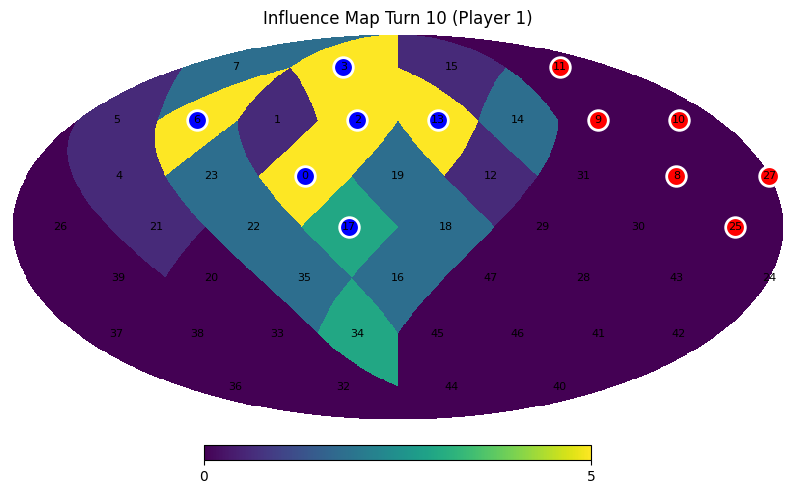

Turn 10.0: Player 0 [Coins: 122] BUILDS ROAD 8-31
Turn 10.1: Player 1 [Coins: 164] BUILDS ROAD 17-34
Turn 11.0: Player 0 [Coins: 146] SETTLES at 31 (Weight 5)
Turn 11.1: Player 1 [Coins: 190] SETTLES at 34 (Weight 5)
Turn 12.0: Player 0 [Coins: 176] BUILDS ROAD 25-42
Turn 12.1: Player 1 [Coins: 222] BUILDS ROAD 34-45
Turn 13.0: Player 0 [Coins: 205] SETTLES at 42 (Weight 5)
Turn 13.1: Player 1 [Coins: 253] SETTLES at 45 (Weight 5)
Turn 14.0: Player 0 [Coins: 240] BUILDS ROAD 42-37
Turn 14.1: Player 1 [Coins: 290] BUILDS ROAD 0-19
Turn 15.0: Player 0 [Coins: 274] SETTLES at 37 (Weight 5)
Turn 15.1: Player 1 [Coins: 326] SETTLES at 19 (Weight 3)
Turn 16.0: Player 0 [Coins: 314] BUILDS ROAD 37-36
Turn 16.1: Player 1 [Coins: 366] BUILDS ROAD 0-23
Turn 17.0: Player 0 [Coins: 353] SETTLES at 36 (Weight 5)
Turn 17.1: Player 1 [Coins: 405] SETTLES at 23 (Weight 3)
Turn 18.0: Player 0 [Coins: 398] BUILDS ROAD 36-39
Turn 18.1: Player 1 [Coins: 448] BUILDS ROAD 0-22
Turn 19.0: Player 0 [Coins: 44

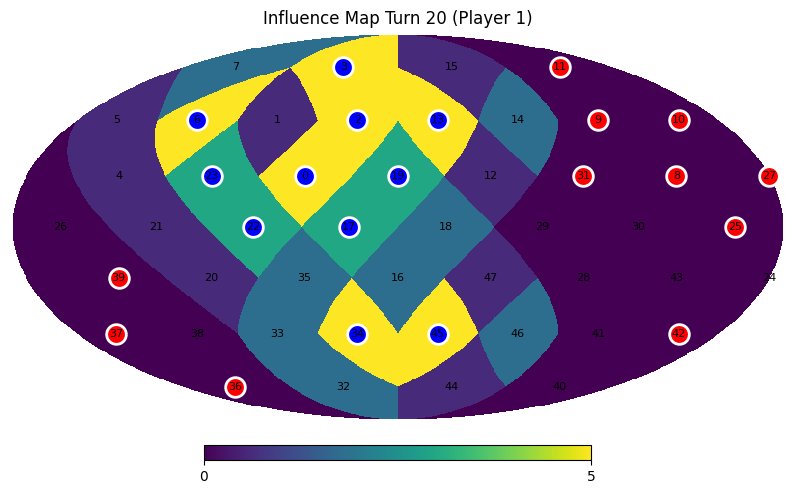

Turn 20.0: Player 0 [Coins: 492] BUILDS ROAD 42-41
Turn 20.1: Player 1 [Coins: 536] BUILDS ROAD 0-35
Turn 21.0: Player 0 [Coins: 541] SETTLES at 41 (Weight 5)
Turn 21.1: Player 1 [Coins: 581] SETTLES at 35 (Weight 3)
Turn 22.0: Player 0 [Coins: 596] BUILDS ROAD 41-28
Turn 22.1: Player 1 [Coins: 630] BUILDS ROAD 3-7
Turn 23.0: Player 0 [Coins: 650] SETTLES at 28 (Weight 5)
Turn 23.1: Player 1 [Coins: 678] SETTLES at 7 (Weight 3)
Turn 24.0: Player 0 [Coins: 710] BUILDS ROAD 28-29
Turn 24.1: Player 1 [Coins: 730] BUILDS ROAD 35-16
Turn 25.0: Player 0 [Coins: 769] SETTLES at 29 (Weight 5)
Turn 25.1: Player 1 [Coins: 781] SETTLES at 16 (Weight 3)
Turn 26.0: Player 0 [Coins: 834] BUILDS ROAD 36-32
Turn 26.1: Player 1 [Coins: 836] BUILDS ROAD 35-33
Turn 27.0: Player 0 [Coins: 898] SETTLES at 32 (Weight 3)
Turn 27.1: Player 1 [Coins: 890] SETTLES at 33 (Weight 3)
Turn 28.0: Player 0 [Coins: 966] BUILDS ROAD 8-30
Turn 28.1: Player 1 [Coins: 948] BUILDS ROAD 13-14
Turn 29.0: Player 0 [Coins: 103

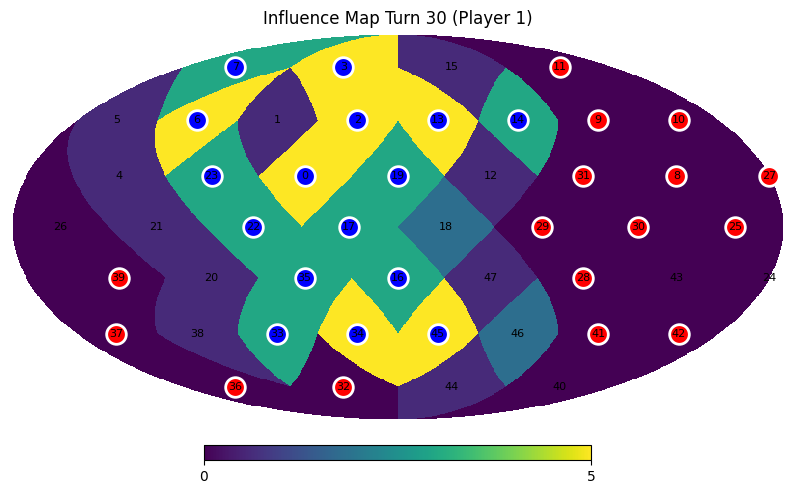

Turn 30.0: Player 0 [Coins: 1104] BUILDS ROAD 41-46
Turn 30.1: Player 1 [Coins: 1066] BUILDS ROAD 13-18
Turn 31.0: Player 0 [Coins: 1174] SETTLES at 46 (Weight 3)
Turn 31.1: Player 1 [Coins: 1126] SETTLES at 18 (Weight 3)
Turn 32.0: Player 0 [Coins: 1248] BUILDS ROAD 32-44
Turn 32.1: Player 1 [Coins: 1190] BUILDS ROAD 0-1
Turn 33.0: Player 0 [Coins: 1321] SETTLES at 44 (Weight 1)
Turn 33.1: Player 1 [Coins: 1253] SETTLES at 1 (Weight 1)
Turn 34.0: Player 0 [Coins: 1396] BUILDS ROAD 32-38
Turn 34.1: Player 1 [Coins: 1318] BUILDS ROAD 2-15
Turn 35.0: Player 0 [Coins: 1470] SETTLES at 38 (Weight 1)
Turn 35.1: Player 1 [Coins: 1382] SETTLES at 15 (Weight 1)
Turn 36.0: Player 0 [Coins: 1546] BUILDS ROAD 8-43
Turn 36.1: Player 1 [Coins: 1448] BUILDS ROAD 6-5
Turn 37.0: Player 0 [Coins: 1621] SETTLES at 43 (Weight 1)
Turn 37.1: Player 1 [Coins: 1513] SETTLES at 5 (Weight 1)
Turn 38.0: Player 0 [Coins: 1698] BUILDS ROAD 25-24
Turn 38.1: Player 1 [Coins: 1580] BUILDS ROAD 5-4
Turn 39.0: Player 

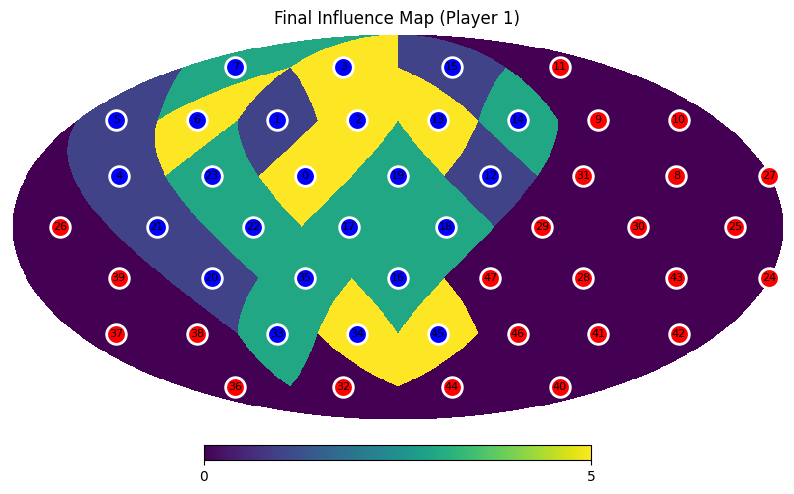

In [9]:
print("\n--- Simulation: Week 2 Greedy (P0) vs Influence (P1) ---")
np.random.seed(202) # Different seed for variety
agent0 = GreedyAgent(0)
agent1 = InfluenceAgent(1, alpha=0.6)
game_w2 = Game(agent0, agent1)
# Pass plotting directive: Plot for Player 1 (Influence Agent)
history = game_w2.play(plot_influence_for_player=1)

print("\n--- Final Visualization ---")
# Visualize final influence map for the Influence Agent with complete game state overlay
print("Visualizing Influence Map for Player 1...")
influence_map = agent1.compute_influence(game_w2)
visualize_influence(influence_map, game_instance=game_w2, title="Final Influence Map (Player 1)")

## Week 3: Analysis & Comparisons

This section implements map design customization, batch simulation loops, and visualization of agent performance.

In [10]:
def generate_map_weights(map_type="random", npix=48, seed=None):
    """
    Generates custom map topologies.
    - Random: Uniformly random distribution [1, 3, 5].
    - Clustered: High-value (5) centers with medium-value (3) neighbors.
    - Sparse: Rare high-value (5) outliers in a sea of low value (1).
    """
    rng = np.random.RandomState(seed)
    # Standardize to INTEGERS to match Week 1 environment
    weights = np.ones(npix, dtype=int) * 1  
    
    if map_type == "random":
        weights = rng.choice([1, 3, 5], size=npix)
        
    elif map_type == "clustered":
        # Create high value centers
        centers = rng.choice(npix, size=3, replace=False)
        weights[centers] = 5
        for c in centers:
            neighbors = hp.get_all_neighbours(NSIDE, c, nest=True)
            for n in neighbors:
                # Use uniform() for robustness across numpy versions
                if n != -1 and rng.uniform() > 0.3: # 70% chance of being high val
                    weights[n] = 3
                    
    elif map_type == "sparse":
        # Mostly 1s, rare 5s
        high_vals = rng.choice(npix, size=5, replace=False)
        weights[high_vals] = 5
        
    return weights

def run_simulation_batch(agent_classes, map_type, n_games=50):
    """Runs N games silently and collects statistics."""
    results = {"p0_wins": 0, "p1_wins": 0, "draws": 0, "p0_coins": [], "p1_coins": []}
    
    for i in range(n_games):
        # Setup agents
        a0 = agent_classes[0](0)
        a1 = agent_classes[1](1)
        
        # Setup game
        game = Game(a0, a1)
        # Inject custom map weights
        game.map.weights = generate_map_weights(map_type, seed=i*100)
        
        # Play (silent)
        game.play(verbose=False)
        
        # Metrics
        results["p0_coins"].append(game.agents[0].coins)
        results["p1_coins"].append(game.agents[1].coins)
        
        if game.agents[0].coins > game.agents[1].coins:
            results["p0_wins"] += 1
        elif game.agents[1].coins > game.agents[0].coins:
            results["p1_wins"] += 1
        else:
            results["draws"] += 1
            
    return results

In [11]:
print("Running Week 3 Comparisons (this may take a moment)...")

# Scenarios
scenarios = [
    ("Greedy vs Greedy", [GreedyAgent, GreedyAgent], "random"),
    ("Greedy vs Influence", [GreedyAgent, InfluenceAgent], "random"),
    ("Influence vs Influence", [InfluenceAgent, InfluenceAgent], "random"),
    ("Greedy vs Influence (Clustered)", [GreedyAgent, InfluenceAgent], "clustered"),
    ("Greedy vs Influence (Sparse)", [GreedyAgent, InfluenceAgent], "sparse")
]

comparison_data = {}

for name, agents, map_type in scenarios:
    print(f"Running {name}...")
    comparison_data[name] = run_simulation_batch(agents, map_type, n_games=50)

print("Done.")

Running Week 3 Comparisons (this may take a moment)...
Running Greedy vs Greedy...
Running Greedy vs Influence...
Running Influence vs Influence...
Running Greedy vs Influence (Clustered)...
Running Greedy vs Influence (Sparse)...
Done.


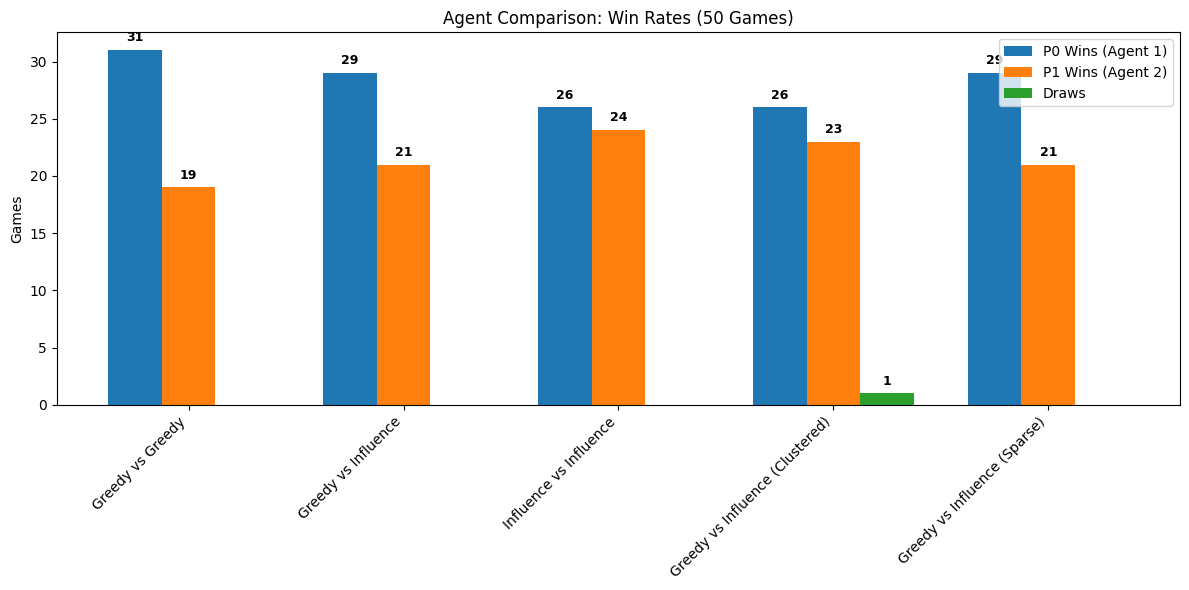

In [12]:
def plot_results(data):
    """Plots a bar chart of match results with numeric labels."""
    labels = list(data.keys())
    p0_wins = [d['p0_wins'] for d in data.values()]
    p1_wins = [d['p1_wins'] for d in data.values()]
    draws = [d['draws'] for d in data.values()]

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width, p0_wins, width, label='P0 Wins (Agent 1)')
    rects2 = ax.bar(x, p1_wins, width, label='P1 Wins (Agent 2)')
    rects3 = ax.bar(x + width, draws, width, label='Draws')

    ax.set_ylabel('Games')
    ax.set_title('Agent Comparison: Win Rates (50 Games)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    
    # 1. Legend at appropriate place (Upper Right)
    ax.legend(loc='upper right')
    
    # 2. Add numeric values on top of bars
    def add_labels(rects):
        for rect in rects:
            height = rect.get_height()
            if height > 0:
                ax.text(rect.get_x() + rect.get_width()/2., height + 0.5,
                        f'{int(height)}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

    add_labels(rects1)
    add_labels(rects2)
    add_labels(rects3)
    
    plt.tight_layout()
    plt.show()

plot_results(comparison_data)

Running Alpha Sensitivity Sweep...


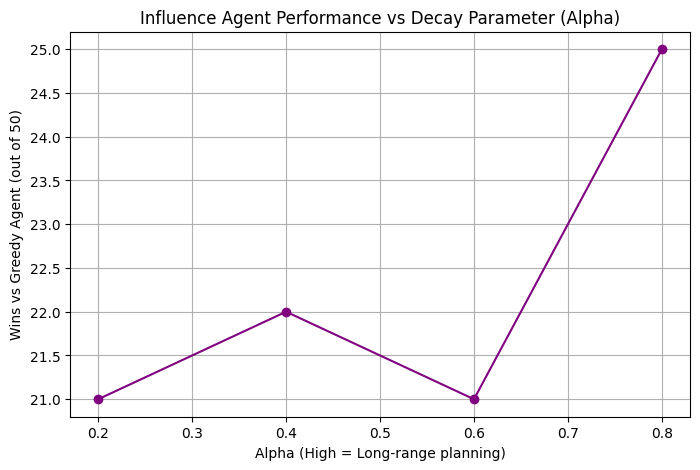

In [13]:
print("Running Alpha Sensitivity Sweep...")

# 1. Alpha Sensitivity Sweep
# Does being "shortsighted" (Low Alpha) or "longsighted" (High Alpha) work better?
alpha_values = [0.2, 0.4, 0.6, 0.8]
alpha_results = []

for alpha in alpha_values:
    # Run a batch of Greedy (P0) vs Influence(alpha) (P1)
    # We define a custom lambda/class wrapper to pass the alpha
    class TunedInfluenceAgent(InfluenceAgent):
        def __init__(self, player_id):
            super().__init__(player_id, alpha=alpha)
    
    res = run_simulation_batch([GreedyAgent, TunedInfluenceAgent], "random", n_games=50)
    # We care about P1's win rate
    alpha_results.append(res['p1_wins'])

# Plot Alpha Sensitivity
plt.figure(figsize=(8, 5))
plt.plot(alpha_values, alpha_results, marker='o', linestyle='-', color='purple')
plt.title("Influence Agent Performance vs Decay Parameter (Alpha)")
plt.xlabel("Alpha (High = Long-range planning)")
plt.ylabel("Wins vs Greedy Agent (out of 50)")
plt.grid(True)
plt.show()

Generating Game Progression Plots...


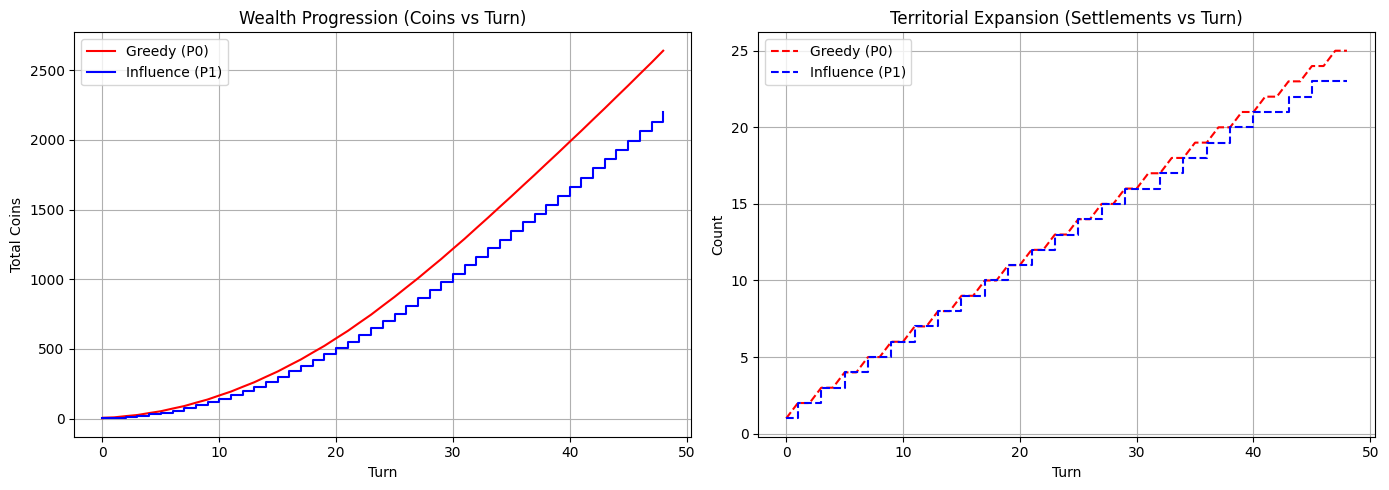

In [14]:
print("Generating Game Progression Plots...")

# 2. Game Progression Plots (Coins over Turn)
# We run ONE Detailed Game to visualize the race dynamics
np.random.seed(303)
demo_game = Game(GreedyAgent(0), InfluenceAgent(1, alpha=0.6))
# CORRECTION: We call play() but access .history property directly
# because the default return inside 'if verbose' is skipped when verbose=False.
# This avoids a NoneType error without modifying the core Game class.
demo_game.play(verbose=False)
history = demo_game.history

# Extract time series
turns = [s['turn'] for s in history]
p0_coins = [s['coins'][0] for s in history]
p1_coins = [s['coins'][1] for s in history]

# Extract Settlements count
p0_settlements = []
p1_settlements = []
for s in history:
    owners = list(s['settlements'].values())
    p0_settlements.append(owners.count(0))
    p1_settlements.append(owners.count(1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Wealth Accumulation
ax1.plot(turns, p0_coins, label="Greedy (P0)", color='red')
ax1.plot(turns, p1_coins, label="Influence (P1)", color='blue')
ax1.set_title("Wealth Progression (Coins vs Turn)")
ax1.set_xlabel("Turn")
ax1.set_ylabel("Total Coins")
ax1.legend()
ax1.grid(True)

# Plot 2: Territorial Expansion
ax2.plot(turns, p0_settlements, label="Greedy (P0)", color='red', linestyle='--')
ax2.plot(turns, p1_settlements, label="Influence (P1)", color='blue', linestyle='--')
ax2.set_title("Territorial Expansion (Settlements vs Turn)")
ax2.set_xlabel("Turn")
ax2.set_ylabel("Count")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()